# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** U P Bhandavya  **Roll No.:** 1RUA25CSE0494  **Section:** G

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [2]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [3]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
print("Shape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.21

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [5]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]
results = []

for feature in FEATURES:
    results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Mode": df[feature].mode()[0]
    })

q2_table = pd.DataFrame(results)

print(q2_table)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode()[0])

                      Feature      Mean   Median    Mode
0    workout_duration_minutes    54.618    54.35    57.8
1  monthly_membership_fee_inr  2283.067  2030.00  1440.0
2       attendance_percentage    84.210    85.10    85.1
3          weekly_visit_count     3.337     2.40     2.3

Mode of preferred_workout:
Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**
The feature with the largest relative difference between the mean and median is monthly_membership_fee_inr. This gap suggests that the distribution is not perfectly symmetric and is likely affected by higher values or extreme values. Since the mean is greater than the median, I would expect the distribution to have a right (positive) tail.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [6]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
original_mean = df["monthly_membership_fee_inr"].mean()
original_median = df["monthly_membership_fee_inr"].median()

# Make a copy
df_outlier = df.copy()

# Add hypothetical ₹80,000 value
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

new_mean = df_outlier["monthly_membership_fee_inr"].mean()
new_median = df_outlier["monthly_membership_fee_inr"].median()

comparison = pd.DataFrame({
    "Statistic": ["Mean", "Median"],
    "Before": [original_mean, original_median],
    "After": [new_mean, new_median]
})

print(comparison)

  Statistic    Before     After
0      Mean  2283.067  2797.748
1    Median  2030.000  2030.000


**Your answer:**

The mean increases noticeably after adding the ₹80,000 value because the mean uses every observation, so an extremely large value has a strong effect on the result. The median changes very little because it depends mainly on the middle value after the observations are ordered, making it much less sensitive to a single extreme value.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [8]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
x = df["workout_duration_minutes"]

# Step 1: Number of observations
n = len(x)

# Step 2: Mean
mean_x = sum(x) / n
print("Mean:")
print(mean_x)

# Step 3: Deviations
deviations = x - mean_x
print("\nDeviations:")
print(deviations.to_string(index=False))

# Step 4: Squared deviations
squared_deviations = deviations ** 2
print("\nSquared deviations:")
print(squared_deviations.to_string(index=False))

# Step 5: Sum of squared deviations
sum_squared_deviations = sum(squared_deviations)

print("\nSum of squared deviations:")
print(sum_squared_deviations)

# Step 6: Sample variance
variance_manual = sum_squared_deviations / (n - 1)

print("\nManual sample variance:")
print(variance_manual)

# Step 7: Standard deviation
std_manual = np.sqrt(variance_manual)

print("\nManual sample standard deviation:")
print(std_manual)

# Verification
variance_numpy = np.var(x, ddof=1)
std_numpy = np.std(x, ddof=1)

print("\nVerification using NumPy:")
print("np.var(ddof=1):", variance_numpy)
print("np.std(ddof=1):", std_numpy)

print("\nVariance matches:",
      np.isclose(variance_manual, variance_numpy))

print("Standard deviation matches:",
      np.isclose(std_manual, std_numpy))

Mean:
54.618

Deviations:
 15.082
 26.382
  7.982
 11.082
 -5.318
-15.518
 -2.318
 18.382
-21.918
 -5.518
-22.618
  1.682
 10.882
-14.518
 -4.518
 16.282
 -0.718
-14.518
-15.418
-23.818
  9.682
 -8.618
 12.982
 10.782
 -7.518
 -5.918
  9.682
  2.182
  3.582
-19.418
 11.182
-10.118
-26.818
 -7.018
  5.482
 25.582
 -4.118
-15.618
 25.882
  2.282
 -2.718
-12.518
-11.618
 18.082
 -2.818
 -6.118
 -5.718
 19.182
 -6.718
  7.882
  3.582
  3.282
-10.118
  8.282
 19.682
 -0.218
-10.618
-15.118
  2.682
 -2.918
 -0.918
  0.482
-17.318
  9.782
  3.182
 -0.518
  3.182
 11.482
  0.982
 -9.818
 14.382
 -4.818
 -8.318
-18.318
  0.482
-12.218
 -5.818
  5.782
  0.782
 12.582
  4.082
 -4.418
 -3.618
 -5.718
  8.182
  0.682
 -4.518
 10.482
  1.582
 -5.218
-17.718
  5.582
  3.282
  0.982
 -4.818
 -9.618
 -2.318
  3.182
 -1.118
 -1.318
 -5.218
  4.482
  3.182
 -8.618
  9.482
  9.882
 10.182
 -1.218
 -1.918
-13.518
  9.482
-25.218
 -4.318
 -3.718
 10.682
  0.382
-11.218
-16.718
 -8.318
  1.682
  1.082
 -2.01

### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [9]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features


iqr_results = []

for feature in FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    iqr_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

q6_table = pd.DataFrame(iqr_results)

print(q6_table)

                      Feature        Q1        Q3       IQR  Lower Bound  \
0    workout_duration_minutes    48.050    62.875    14.825       25.812   
1  monthly_membership_fee_inr  1515.000  2825.000  1310.000     -450.000   
2       attendance_percentage    80.175    88.775     8.600       67.275   
3          weekly_visit_count     1.800     5.300     3.500       -3.450   

   Upper Bound  Outlier Count  
0       85.113              0  
1     4790.000              2  
2      101.675              1  
3       10.550              0  


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [10]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
shape_results = []

for feature in FEATURES:
    skewness = stats.skew(df[feature], bias=False)
    kurtosis = stats.kurtosis(df[feature], fisher=True, bias=False)

    # Classify skewness
    if skewness > 0.5:
        skew_class = "Right-skewed"
    elif skewness < -0.5:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"

    # Classify kurtosis
    if kurtosis > 0.5:
        kurt_class = "Heavier tails"
    elif kurtosis < -0.5:
        kurt_class = "Lighter tails"
    else:
        kurt_class = "Roughly normal tails"

    shape_results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis,
        "Skewness Classification": skew_class,
        "Kurtosis Interpretation": kurt_class
    })

q7_table = pd.DataFrame(shape_results)

print(q7_table)

                      Feature  Skewness  Excess Kurtosis  \
0    workout_duration_minutes     0.081           -0.160   
1  monthly_membership_fee_inr     1.177            1.863   
2       attendance_percentage    -0.561           -0.324   
3          weekly_visit_count     0.446           -1.375   

   Skewness Classification Kurtosis Interpretation  
0  Approximately symmetric    Roughly normal tails  
1             Right-skewed           Heavier tails  
2              Left-skewed    Roughly normal tails  
3  Approximately symmetric           Lighter tails  


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

I predict that **weekly_visit_count** will be bimodal. In a gym population, there may be one group of casual members who visit only a few times per week and another group of highly committed members who visit very frequently. These two groups could create two separate peaks in the distribution.

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

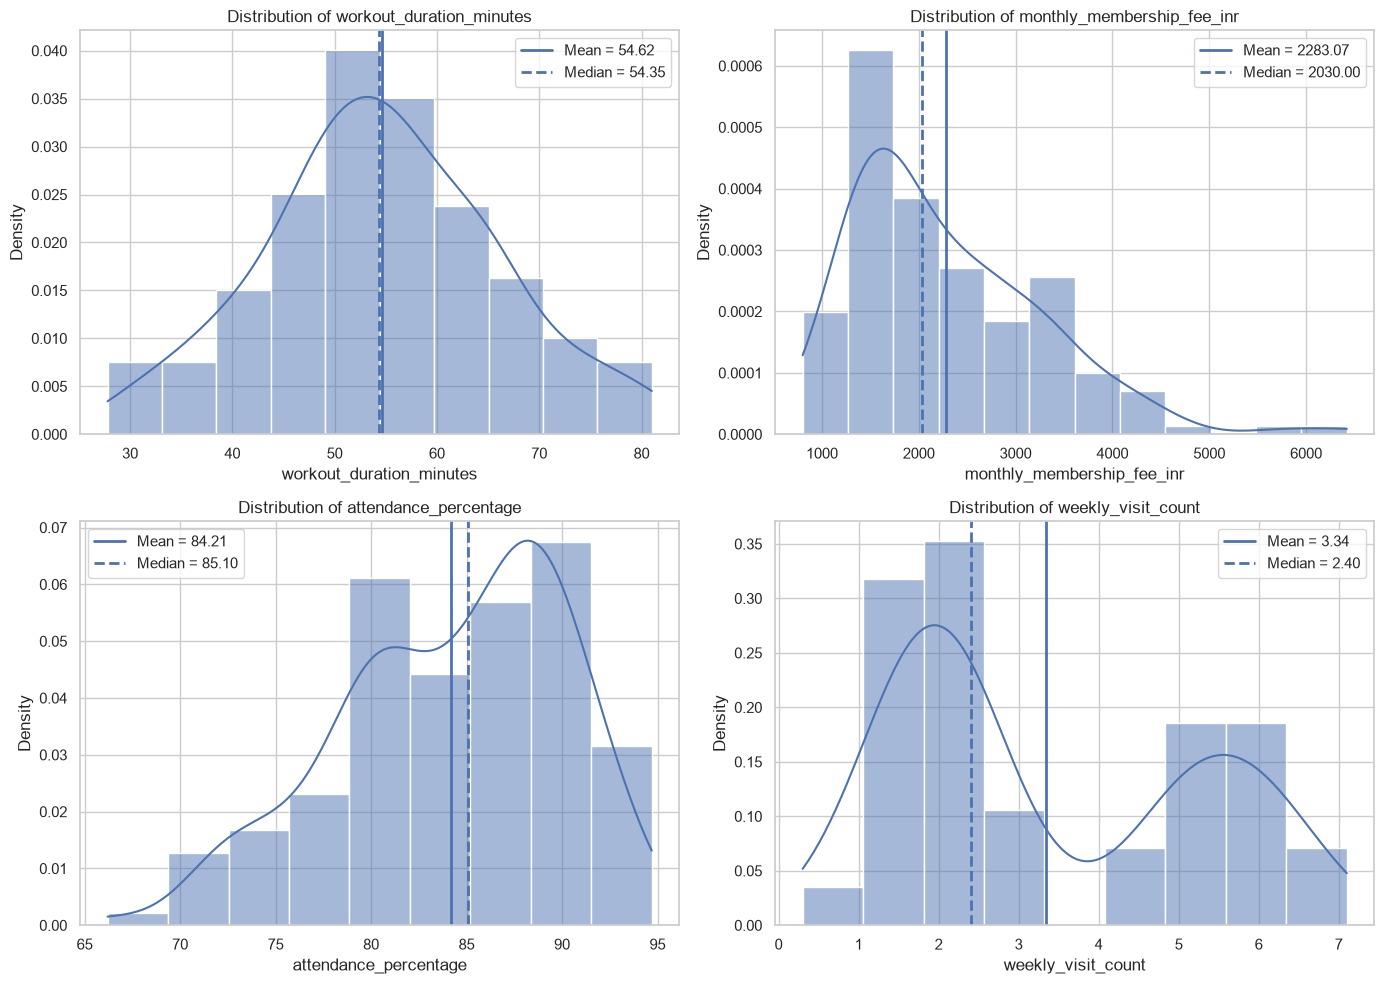

In [13]:
# TODO: Q9 — 2x2 h# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, FEATURES):

    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )

    mean_value = df[feature].mean()
    median_value = df[feature].median()

    ax.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

The histogram confirms my prediction from Q8. The feature weekly_visit_count appears bimodal because its histogram shows two distinct peaks, suggesting that there are two different groups of gym members. The mean is located between the two peaks, so it does fall in an empty valley and therefore is not a particularly representative value.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

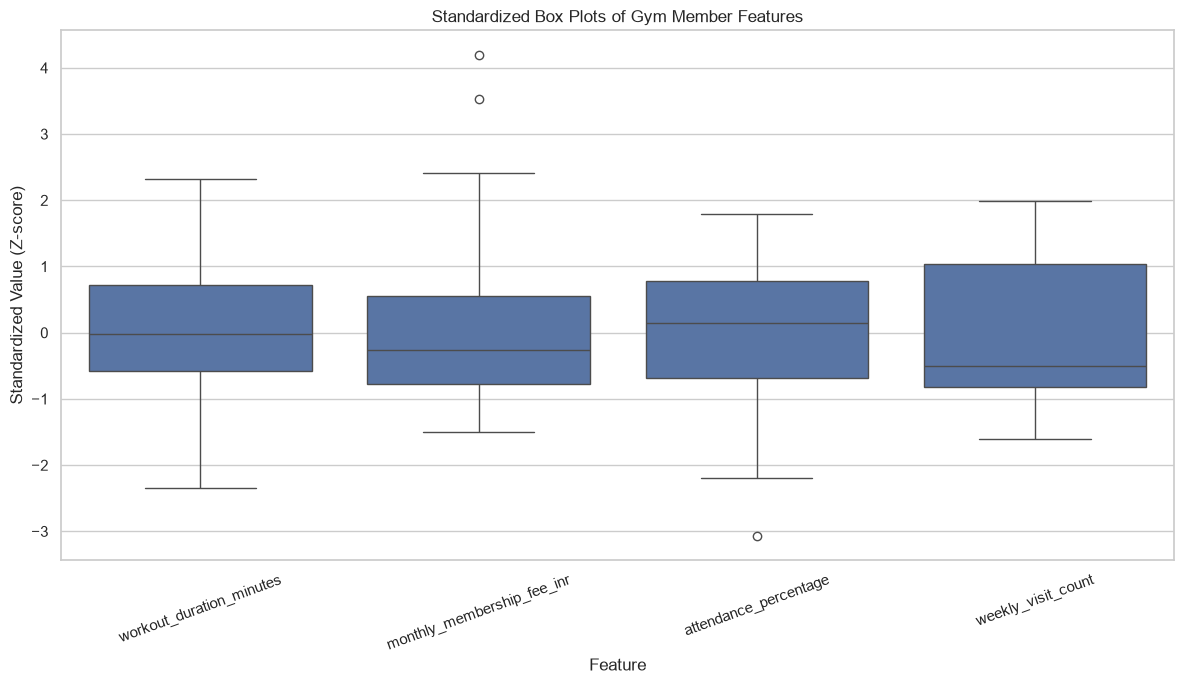

In [14]:


# Calculate z-scores
df_z = df[FEATURES].copy()

for feature in FEATURES:
    df_z[feature] = (
        df[feature] - df[feature].mean()
    ) / df[feature].std()

# Convert to long format for plotting
df_z_long = df_z.melt(
    var_name="Feature",
    value_name="Z-score"
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_z_long,
    x="Feature",
    y="Z-score"
)

plt.title("Standardized Box Plots of Gym Member Features")
plt.xlabel("Feature")
plt.ylabel("Standardized Value (Z-score)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

For the first pair, weekly visit count and workout duration, the Pearson correlation is r = -0.011. The scatter plot does not support my hypothesis because the points show a weak relationship with almost no linear correlation.

For the second pair, monthly membership fee and attendance percentage, the correlation is r = -0.080. The scatter plot supports my hypothesis that the relationship would be weak, since the points appear widely scattered.

Correlation 1:
weekly_visit_count vs workout_duration_minutes = -0.011

Correlation 2:
monthly_membership_fee_inr vs attendance_percentage = -0.080


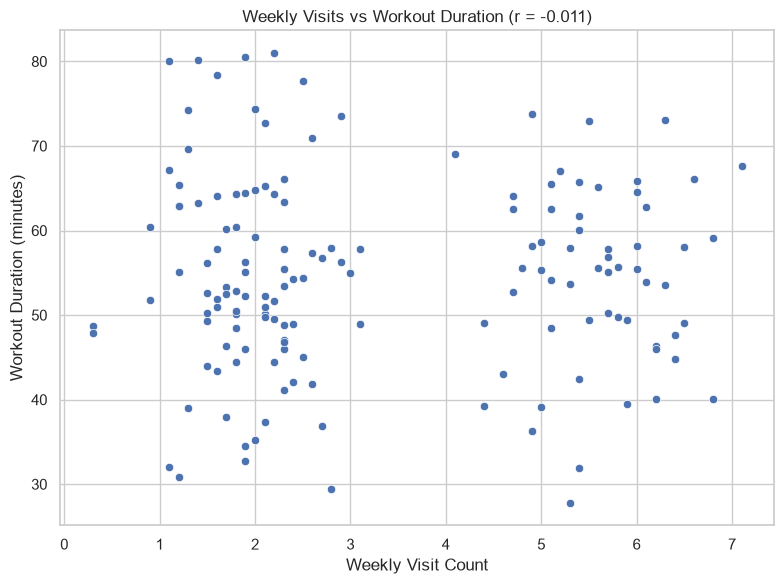

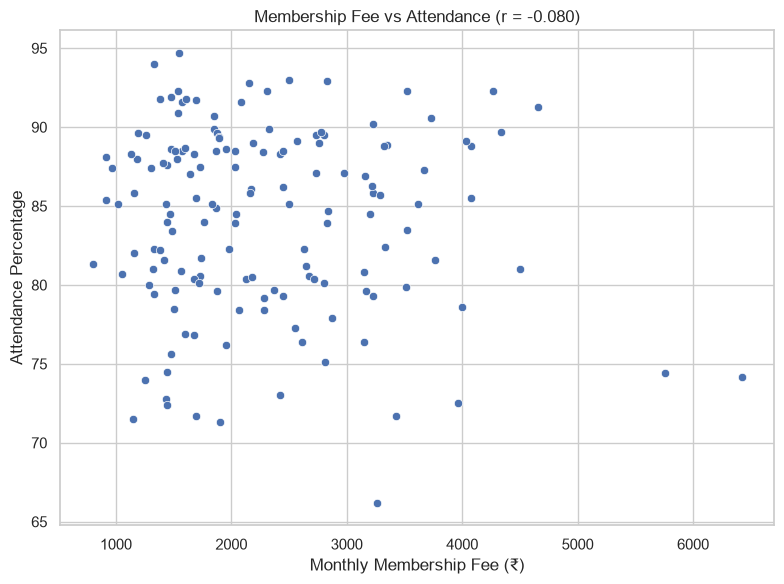

In [16]:
# TODO: Q12 — t# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)


pair1 = (
    "weekly_visit_count",
    "workout_duration_minutes"
)

pair2 = (
    "monthly_membership_fee_inr",
    "attendance_percentage"
)

# Correlations
corr1 = df[pair1[0]].corr(df[pair1[1]])
corr2 = df[pair2[0]].corr(df[pair2[1]])

print("Correlation 1:")
print(f"{pair1[0]} vs {pair1[1]} = {corr1:.3f}")

print("\nCorrelation 2:")
print(f"{pair2[0]} vs {pair2[1]} = {corr2:.3f}")


# Scatter plot 1
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=pair1[0],
    y=pair1[1]
)

plt.title(
    f"Weekly Visits vs Workout Duration "
    f"(r = {corr1:.3f})"
)

plt.xlabel("Weekly Visit Count")
plt.ylabel("Workout Duration (minutes)")

plt.tight_layout()
plt.show()


# Scatter plot 2
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=pair2[0],
    y=pair2[1]
)

plt.title(
    f"Membership Fee vs Attendance "
    f"(r = {corr2:.3f})"
)

plt.xlabel("Monthly Membership Fee (₹)")
plt.ylabel("Attendance Percentage")

plt.tight_layout()
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [17]:
# TODO: Q13 — assemble the comparative summary table# TODO: Q13 — assemble the comparative summary table
# Q13 — Summary table

summary_table = pd.DataFrame({
    "Feature": FEATURES,
    "Mean": [df[f].mean() for f in FEATURES],
    "Median": [df[f].median() for f in FEATURES],
    "Standard Deviation": [df[f].std() for f in FEATURES],
    "IQR": [
        df[f].quantile(0.75) - df[f].quantile(0.25)
        for f in FEATURES
    ],
    "Skewness": [
        stats.skew(df[f], bias=False)
        for f in FEATURES
    ],
    "Excess Kurtosis": [
        stats.kurtosis(df[f], fisher=True, bias=False)
        for f in FEATURES
    ]
})

print(summary_table)

                      Feature      Mean   Median  Standard Deviation  \
0    workout_duration_minutes    54.618    54.35              11.397   
1  monthly_membership_fee_inr  2283.067  2030.00             984.837   
2       attendance_percentage    84.210    85.10               5.874   
3          weekly_visit_count     3.337     2.40               1.886   

        IQR  Skewness  Excess Kurtosis  
0    14.825     0.081           -0.160  
1  1310.000     1.177            1.863  
2     8.600    -0.561           -0.324  
3     3.500     0.446           -1.375  


**Your answer (recommendation paragraph):**

For workout duration, I would report the mean as the measure of central tendency because its mean and median are close, indicating approximately symmetric data. For dispersion, standard deviation is more appropriate because the skewness is very low (0.081), suggesting that the data is approximately symmetric. For monthly membership fee, the median is preferable because the mean (2283.067) is noticeably higher than the median (2030.00), with positive skewness (1.177) and two outliers, while IQR better represents its spread because it is less affected by the skewness and outliers. For attendance percentage, I would use the median and IQR, since the table shows some left-skewness (-0.561) and one outlier, making these measures more robust to unusual values. Finally, for weekly visit count, the median and IQR are preferable because the distribution is somewhat affected by its bimodal shape, with the mean (3.337) noticeably higher than the median (2.40), while the IQR provides a robust measure of spread. Overall, the choices are based on the observed distribution and spread of each feature rather than applying the same statistic to all four variables.

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [13]:
# TODO (bonus): gro# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
# Bonus — Mean attendance by preferred workout

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .sort_values(ascending=False)
)

print(attendance_by_workout)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=attendance_by_workout.index,
    y=attendance_by_workout.values
)

plt.title("Average Attendance Percentage by Preferred Workout")
plt.xlabel("Preferred Workout")
plt.ylabel("Mean Attendance Percentage")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()upby preferred_workout, compare mean attendance_percentage across categories

---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed